# NBA Player Performance Analysis (2010–2020)

This project analyzes NBA player statistics between 2010 and 2020.

The analysis focuses on:
- Physical attributes and performance
- Draft position and player success
- NBA performance trends
- Geographic distribution of top scorers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = 'D:\\Data4Analytics\\'
df = pd.read_csv(path + 'players_stats_by_season_full_details.csv')

In [3]:
# Filter data for the 2010–2020 period (modern NBA era).
seasons_to_keep = [
    '2010 - 2011', '2011 - 2012', '2012 - 2013', '2013 - 2014',
    '2014 - 2015', '2015 - 2016', '2016 - 2017', '2017 - 2018',
    '2018 - 2019', '2019 - 2020'
]
df = df[df['Season'].isin(seasons_to_keep)].copy()

print(sorted(df['Season'].unique()))
print(len(df))

['2010 - 2011', '2011 - 2012', '2012 - 2013', '2013 - 2014', '2014 - 2015', '2015 - 2016', '2016 - 2017', '2017 - 2018', '2018 - 2019', '2019 - 2020']
42913


In [4]:
# Perform data cleaning and create three categorical variables for analysis.

df['height_cm'] = pd.to_numeric(df['height_cm'], errors='coerce')
df['weight_kg'] = pd.to_numeric(df['weight_kg'], errors='coerce')

df['performance_tier'] = pd.cut(
    df['PTS'],
    bins=[-1, 5, 10, 20, 100],
    labels=['Below Average', 'Average', 'Good', 'Elite']
)

df['size_category'] = pd.cut(
    df['height_cm'],
    bins=[0, 185, 200, 230],
    labels=['Guard', 'Forward', 'Center']
)

df['draft_tier'] = pd.cut(
    df['draft_pick'],
    bins=[0, 5, 15, 30],
    labels=['Top 5', 'Lottery', 'Late 1st Round']
)

print(df['performance_tier'].value_counts())
print(df['size_category'].value_counts())
print(df['draft_tier'].value_counts())

performance_tier
Elite            6290
Good              421
Average           160
Below Average      83
Name: count, dtype: int64
size_category
Forward    19432
Center     17921
Guard       5486
Name: count, dtype: int64
draft_tier
Late 1st Round    2707
Lottery           1862
Top 5             1202
Name: count, dtype: int64


# Physical Attributes vs Performance

This section examines the relationship between player physical characteristics and on-court performance.

The analysis focuses on points, rebounds and assists across different size categories.

In [5]:
# PHYSICAL ATTRIBUTES vs PERFORMANCE
df_physical = df[df['height_cm'].notna() & df['weight_kg'].notna()].copy()
# Metrics.
print(df_physical.groupby('size_category', observed=True)['PTS'].mean().round(2))
print(df_physical.groupby('size_category', observed=True)['REB'].mean().round(2))
print(df_physical.groupby('size_category', observed=True)['AST'].mean().round(2))
print(df_physical.groupby('performance_tier', observed=True)['height_cm'].mean().round(1))

size_category
Guard      322.78
Forward    303.14
Center     320.37
Name: PTS, dtype: float64
size_category
Guard       80.07
Forward     97.75
Center     165.34
Name: REB, dtype: float64
size_category
Guard      112.52
Forward     70.57
Center      42.85
Name: AST, dtype: float64
performance_tier
Below Average    195.2
Average          195.9
Good             197.3
Elite            197.6
Name: height_cm, dtype: float64


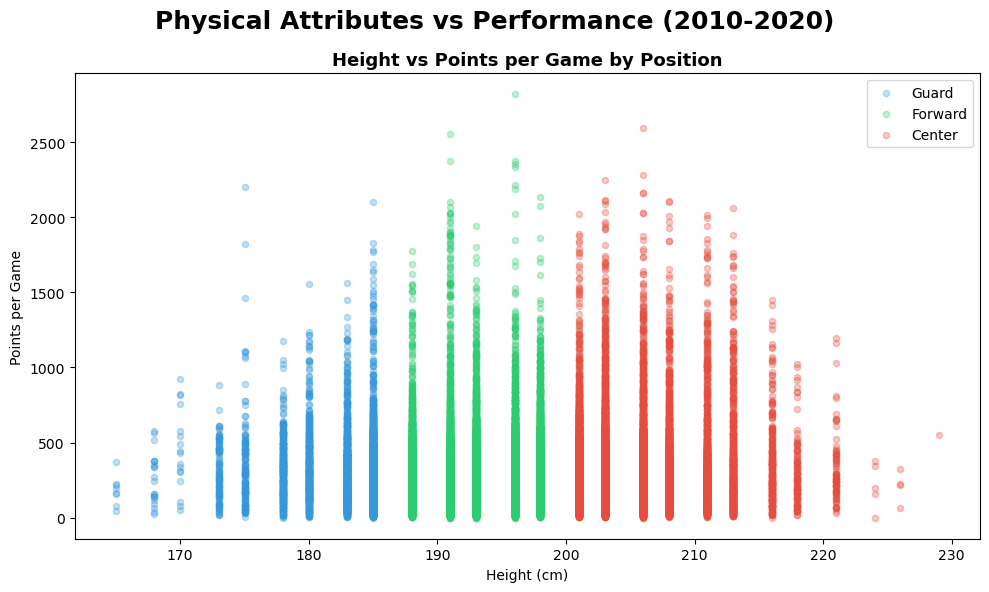

In [6]:
# Charts
# Scatter plot analyzing the relationship between player height and scoring performance.
# The visualization shows that guards are typically shorter but more productive in scoring.
# Centers dominate in rebounds due to height advantage, while guards lead in points and assists.

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('Physical Attributes vs Performance (2010-2020)', fontsize=18, fontweight='bold')

colors_size = {'Guard': '#3498DB', 'Forward': '#2ECC71', 'Center': '#E74C3C'}
for size, color in colors_size.items():
    subset = df_physical[df_physical['size_category'] == size]
    ax.scatter(subset['height_cm'], subset['PTS'],
               label=size, color=color, alpha=0.3, s=20)

ax.set_title('Height vs Points per Game by Position', fontsize=13, fontweight='bold')
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Points per Game')
ax.legend()

plt.tight_layout()
plt.savefig(path + 'section1_physical_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Draft Position Analysis

This section investigates whether draft position is associated with future player performance.

Players are grouped into different draft tiers and compared using scoring and playing time statistics.

In [7]:
# DRAFT ANALYSIS
df_draft = df[df['draft_pick'].notna()].copy()
# Metrics.
print(df_draft.groupby('draft_tier', observed=True)['PTS'].mean().sort_values(ascending=False).round(2))
print(df_draft.groupby('draft_tier', observed=True)['MIN'].mean().sort_values(ascending=False).round(2))
print(df_draft.groupby('draft_pick')['PTS'].mean().head(10).round(2))

top_drafted = df_draft.groupby('Player').agg(
    draft_pick=('draft_pick', 'first'),
    avg_pts=('PTS', 'mean'),
    avg_min=('MIN', 'mean')
).dropna().sort_values('avg_pts', ascending=False).head(10)
print(top_drafted.round(2))

draft_tier
Top 5             592.64
Lottery           504.63
Late 1st Round    381.38
Name: PTS, dtype: float64
draft_tier
Top 5             1211.72
Lottery           1104.49
Late 1st Round     880.66
Name: MIN, dtype: float64
draft_pick
1.0     684.71
2.0     584.29
3.0     630.89
4.0     577.63
5.0     505.68
6.0     533.79
7.0     518.56
8.0     463.38
9.0     578.46
10.0    556.86
Name: PTS, dtype: float64
                    draft_pick  avg_pts  avg_min
Player                                          
Trae Young                 5.0  1663.50  2311.70
Joe Young                 13.0  1620.00  1791.90
Devin Booker              13.0  1584.25  2398.02
Andrea Bargnani            1.0  1414.00  2353.10
Nick Fazekas               4.0  1384.00  1741.68
Karl-Anthony Towns         1.0  1364.83  2079.37
Collin Sexton              8.0  1360.00  2373.85
Andre Emmett               6.0  1311.00  1619.57
DeMarcus Cousins           5.0  1296.12  1963.04
Lester Hudson             28.0  1293.38  1733.3

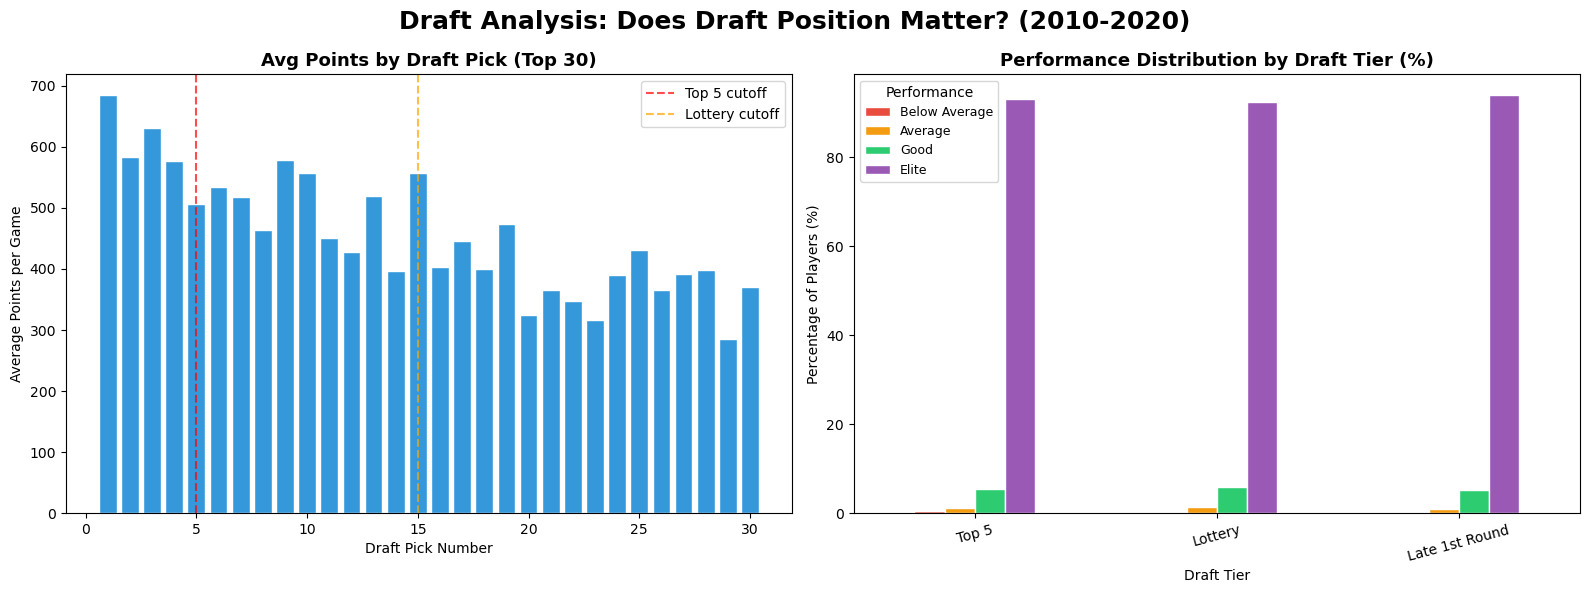

In [8]:
# Charts
# Chart 2a: Bar chart showing whether the #1 draft pick is truly the best performer.
# Chart 2b: Stacked bar chart showing the percentage of players in each draft tier
# (Below Average, Average, Good, Elite).

# In the first chart, Top 5 picks show on average 211 more points than Late 1st Round picks.
# The #1 draft pick does not always guarantee the best performance — there are hidden gems
# even among picks 15–30.

# In the second chart, we observe the distribution of performance tiers:
# Top 5 picks have a higher proportion of Elite players.

# Conclusion: draft position matters, but it is not an absolute guarantee of success.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Draft Analysis: Does Draft Position Matter? (2010-2020)',
             fontsize=18, fontweight='bold')

draft_pts = df_draft[df_draft['draft_pick'] <= 30].groupby('draft_pick')['PTS'].mean()
axes[0].bar(draft_pts.index, draft_pts.values, color='#3498DB', edgecolor='white')
axes[0].set_title('Avg Points by Draft Pick (Top 30)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Draft Pick Number')
axes[0].set_ylabel('Average Points per Game')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Top 5 cutoff')
axes[0].axvline(x=15, color='orange', linestyle='--', alpha=0.7, label='Lottery cutoff')
axes[0].legend()

draft_perf = df_draft.groupby(['draft_tier', 'performance_tier'], observed=True).size().unstack(fill_value=0)
draft_perf_pct = draft_perf.div(draft_perf.sum(axis=1), axis=0) * 100
draft_perf_pct.plot(kind='bar', ax=axes[1],
                    color=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6'],
                    edgecolor='white')
axes[1].set_title('Performance Distribution by Draft Tier (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Draft Tier')
axes[1].set_ylabel('Percentage of Players (%)')
axes[1].legend(title='Performance', fontsize=9)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(path + 'section2_draft_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# NBA Performance Analysis

This section focuses exclusively on NBA players and examines overall performance trends and player quality distribution.

In [9]:
# NBA ANALYSIS
df_leagues = df[df['League'] == 'NBA'].copy()
# Metrics. 
print(df_leagues.groupby('League', observed=True)['PTS'].mean().round(2))
print(df_leagues.groupby('League', observed=True)['MIN'].mean().round(2))
print(df_leagues.groupby('League', observed=True)['height_cm'].mean().round(1))

top_nat = df_leagues['nationality'].value_counts().head(3)
print(top_nat)

League
NBA    540.29
Name: PTS, dtype: float64
League
NBA    1227.89
Name: MIN, dtype: float64
League
NBA    200.8
Name: height_cm, dtype: float64
nationality
United States    2930
France             87
Canada             76
Name: count, dtype: int64


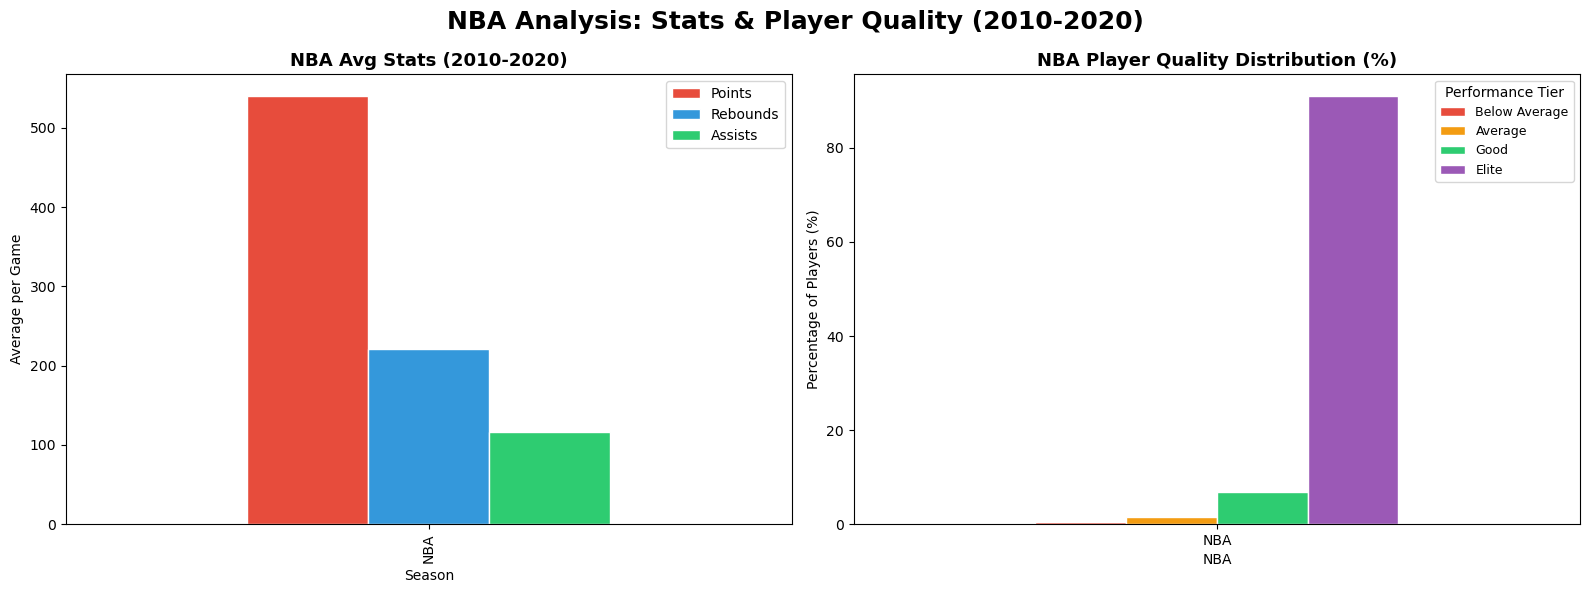

In [10]:
# Charts
# Chart 3a: Bar chart showing average NBA player statistics.
# Chart 3b: Distribution of player quality in the NBA.

# The NBA is the most competitive basketball league in the world.
# On average, a player scores around 540 points per season.

# The second chart shows the distribution of player quality,
# indicating how many players fall into Elite, Good, Average, and Below Average categories.

# This highlights the competitiveness of the NBA, where even "Average" players
# are among the best basketball players in the world.

# Conclusion: The 2010–2020 NBA era represents a balance between elite stars
# and role players.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NBA Analysis: Stats & Player Quality (2010-2020)',
             fontsize=18, fontweight='bold')

league_stats = df_leagues.groupby('League', observed=True)[['PTS', 'REB', 'AST']].mean()
league_stats.plot(kind='bar', ax=axes[0],
                  color=['#E74C3C', '#3498DB', '#2ECC71'],
                  edgecolor='white')
axes[0].set_title('NBA Avg Stats (2010-2020)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average per Game')
axes[0].legend(['Points', 'Rebounds', 'Assists'])
plt.xticks(rotation=0)

league_perf = df_leagues.groupby(['League', 'performance_tier'], observed=True).size().unstack(fill_value=0)
league_perf_pct = league_perf.div(league_perf.sum(axis=1), axis=0) * 100
league_perf_pct.plot(kind='bar', ax=axes[1],
                     color=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6'],
                     edgecolor='white')
axes[1].set_title('NBA Player Quality Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('NBA')
axes[1].set_ylabel('Percentage of Players (%)')
axes[1].legend(title='Performance Tier', fontsize=9)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(path + 'section3_nba_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# SUMMARY

best_scoring_position = df_physical.groupby('size_category', observed=True)['PTS'].mean().idxmax()
best_rebounding_position = df_physical.groupby('size_category', observed=True)['REB'].mean().idxmax()
print(best_scoring_position)
print(best_rebounding_position)

top5_avg = df_draft[df_draft['draft_tier'] == 'Top 5']['PTS'].mean()
late_avg = df_draft[df_draft['draft_tier'] == 'Late 1st Round']['PTS'].mean()
print(round(top5_avg, 2))
print(round(late_avg, 2))
print(round(top5_avg - late_avg, 2))

nba_avg = df_leagues['PTS'].mean()
print(round(nba_avg, 2))

Guard
Center
592.64
381.38
211.26
540.29


In [12]:
print(df.columns.tolist())
print(df['Stage'].unique())

['League', 'Season', 'Stage', 'Player', 'Team', 'GP', 'MIN', 'FGM', 'FGA', '3PM', '3PA', 'FTM', 'FTA', 'TOV', 'PF', 'ORB', 'DRB', 'REB', 'AST', 'STL', 'BLK', 'PTS', 'birth_year', 'birth_month', 'birth_date', 'height', 'height_cm', 'weight', 'weight_kg', 'nationality', 'high_school', 'draft_round', 'draft_pick', 'draft_team', 'performance_tier', 'size_category', 'draft_tier']
['International' 'Regular_Season' 'Playoffs']


# Top Scorers Analysis

The objective of this section is to identify the highest-scoring players during the 2010–2020 period.

Regular season and playoff performances are analyzed separately using points per game (PPG).

In [13]:
df_modern = df

In [14]:
df_modern_top_scorers_regular_season = df_modern[df_modern['Stage'] == 'Regular_Season']
df_modern_top_scorers_playoffs = df_modern[df_modern['Stage'] == 'Playoffs']

In [15]:
df_modern_top_scorers_regular_season = df_modern_top_scorers_regular_season.groupby(['Player','nationality','height'])[['PTS','GP']].sum()
df_modern_top_scorers_regular_season['PPG'] = df_modern_top_scorers_regular_season['PTS'] / df_modern_top_scorers_regular_season['GP']
df_modern_top_scorers_regular_season = df_modern_top_scorers_regular_season[df_modern_top_scorers_regular_season['GP'] >= 200]
df_modern_top_scorers_regular_season=df_modern_top_scorers_regular_season.sort_values(by='PPG', ascending=False).head(100).reset_index()
df_modern_top_scorers_regular_season

,Player,nationality,height,PTS,GP,PPG
0,Kevin Durant,United States,6-9,16287,586,27.793515
1,Kobe Bryant,United States,6-6,5827,218,26.729358
2,James Harden,United States,6-5,20209,757,26.696169
3,LeBron James,United States,6-8,18990,717,26.485356
4,Anthony Davis,United States,6-10,10416,397,26.236776
...,...,...,...,...,...,...
95,Tim Hardaway Jr.,United States,6-6,5066,366,13.841530
96,Aaron Gordon,United States,6-9,4900,356,13.764045
97,Jamal Crawford,United States,6-5,8919,650,13.721538
98,Wilson Chandler,United States,6-9,4040,295,13.694915


In [16]:
df_modern_top_scorers_playoffs = df_modern_top_scorers_playoffs.groupby(['Player','nationality','height'])[['PTS','GP']].sum()
df_modern_top_scorers_playoffs['PPG'] = df_modern_top_scorers_playoffs['PTS'] / df_modern_top_scorers_playoffs['GP']
df_modern_top_scorers_playoffs = df_modern_top_scorers_playoffs[df_modern_top_scorers_playoffs['GP'] >= 25]
df_modern_top_scorers_playoffs=df_modern_top_scorers_playoffs.sort_values(by='PPG', ascending=False).head(100).reset_index()
df_modern_top_scorers_playoffs

,Player,nationality,height,PTS,GP,PPG
0,Kevin Durant,United States,6-9,3893,133,29.270677
1,Anthony Davis,United States,6-10,979,34,28.794118
2,LeBron James,United States,6-8,5410,189,28.624339
3,Stephen Curry,United States,6-3,2968,112,26.500000
4,Russell Westbrook,United States,6-3,2461,98,25.112245
...,...,...,...,...,...,...
95,Raymond Felton,United States,6-1,372,35,10.628571
96,Marcin Gortat,Poland,6-11,424,40,10.600000
97,Jerami Grant,United States,6-9,368,35,10.514286
98,Mike Dunleavy,United States,6-9,271,26,10.423077


In [17]:
common_df = df_modern_top_scorers_regular_season[df_modern_top_scorers_regular_season['Player'].isin(df_modern_top_scorers_playoffs['Player'])][['Player','nationality','height','PPG']]
common_df

,Player,nationality,height,PPG
0,Kevin Durant,United States,6-9,27.793515
2,James Harden,United States,6-5,26.696169
3,LeBron James,United States,6-8,26.485356
4,Anthony Davis,United States,6-10,26.236776
5,Russell Westbrook,United States,6-3,24.977591
...,...,...,...,...
91,Joe Johnson,United States,6-7,14.019064
93,Harrison Barnes,United States,6-8,13.908425
94,Ty Lawson,United States,5-11,13.888268
97,Jamal Crawford,United States,6-5,13.721538


# Geographic Distribution of Elite Scorers

This section examines the countries that produce the highest number of elite scorers in both the regular season and the playoffs.

Interactive world maps are used to visualize the distribution of players across different countries.

In [18]:
df_modern_top_scorers_regular_season.groupby('nationality')[['Player']].count().sort_values(by='Player',ascending=False).reset_index()

,nationality,Player
0,United States,77
1,Canada,2
2,Spain,2
3,France,2
4,Germany,2
5,Australia,1
6,Italy / United States,1
7,United States / Australia,1
8,Switzerland / Montenegro,1
9,Slovenia,1


In [19]:
df_modern_top_scorers_playoffs.groupby('nationality')[['Player']].count().sort_values(by='Player',ascending=False).reset_index()

,nationality,Player
0,United States,76
1,France,3
2,Spain,2
3,Germany,2
4,Argentina,1
5,Lithuania,1
6,United States / Australia,1
7,Slovenia,1
8,Serbia,1
9,Republic of the Congo / Spain,1


In [20]:
common_df.groupby('nationality')[['Player']].count().sort_values(by='Player',ascending=False).reset_index()

,nationality,Player
0,United States,48
1,Germany,2
2,Spain,2
3,Bosnia and Herzegovina / Croatia,1
4,Cameroon,1
5,Canada,1
6,Dominican Republic / United States,1
7,England / South Sudan,1
8,France,1
9,Germany / United States,1


In [21]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [22]:
print(common_df['nationality'].unique())
print(df_modern_top_scorers_regular_season['nationality'].unique())

['United States' 'United States / Australia' 'Greece / Nigeria' 'Germany'
 'Italy' 'Serbia' 'Spain' 'Canada' 'Slovenia' 'England / South Sudan'
 'Cameroon' 'Germany / United States' 'Dominican Republic / United States'
 'France' 'Bosnia and Herzegovina / Croatia' 'Italy / United States']
['United States' 'United States / Australia'
 'United States / Dominican Republic' 'Greece / Nigeria' 'Canada'
 'Germany' 'Italy' 'Serbia' 'Australia' 'Switzerland / Montenegro'
 'Bahamas' 'Spain' 'Slovenia' 'England / South Sudan' 'Cameroon' 'France'
 'Germany / United States' 'Dominican Republic / United States'
 'Bosnia and Herzegovina / Croatia' 'Italy / United States']


In [23]:
import plotly.express as px

In [24]:
# Extract the primary nationality from each record
# (e.g., "United States / Australia" -> "United States")
df_modern_top_scorers_regular_season['primary_nationality'] = (
    df_modern_top_scorers_regular_season['nationality']
    .str.split(' / ')
    .str[0]
    .str.strip()
)

df_modern_top_scorers_playoffs['primary_nationality'] = (
    df_modern_top_scorers_playoffs['nationality']
    .str.split(' / ')
    .str[0]
    .str.strip()
)

common_df['primary_nationality'] = (
    common_df['nationality']
    .str.split(' / ')
    .str[0]
    .str.strip()
)

In [25]:
# Count players by country for the Regular Season
country_counts_regular = (
    df_modern_top_scorers_regular_season
    .groupby('primary_nationality')['Player']
    .count()
    .reset_index()
)
country_counts_regular.columns = ['country', 'player_count']

In [26]:
# Count players by country for the Playoffs
country_counts_playoffs = (
    df_modern_top_scorers_playoffs
    .groupby('primary_nationality')['Player']
    .count()
    .reset_index()
)
country_counts_playoffs.columns = ['country', 'player_count']

In [27]:
# Count players by country for players appearing in both Regular Season and Playoffs
country_counts_common = (
    common_df
    .groupby('primary_nationality')['Player']
    .count()
    .reset_index()
)
country_counts_common.columns = ['country', 'player_count']

print("Regular Season top countries:")
print(country_counts_regular.sort_values('player_count', ascending=False).head(10))

print("\nPlayoffs top countries:")
print(country_counts_playoffs.sort_values('player_count', ascending=False).head(10))

print("\nCommon (Regular + Playoffs) top countries:")
print(country_counts_common.sort_values('player_count', ascending=False).head(10))

Regular Season top countries:
                   country  player_count
15           United States            79
8                  Germany             3
4                   Canada             2
7                   France             2
10                   Italy             2
13                   Spain             2
0                Australia             1
1                  Bahamas             1
2   Bosnia and Herzegovina             1
3                 Cameroon             1

Playoffs top countries:
                  country  player_count
16          United States            78
6                  France             3
7                 Germany             3
15                  Spain             2
9                   Italy             2
10              Lithuania             1
14               Slovenia             1
13                 Serbia             1
12  Republic of the Congo             1
11                 Poland             1

Common (Regular + Playoffs) top countries:
          

C:\Users\Savvas\AppData\Local\Temp\ipykernel_18160\94726822.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig1 = px.choropleth(


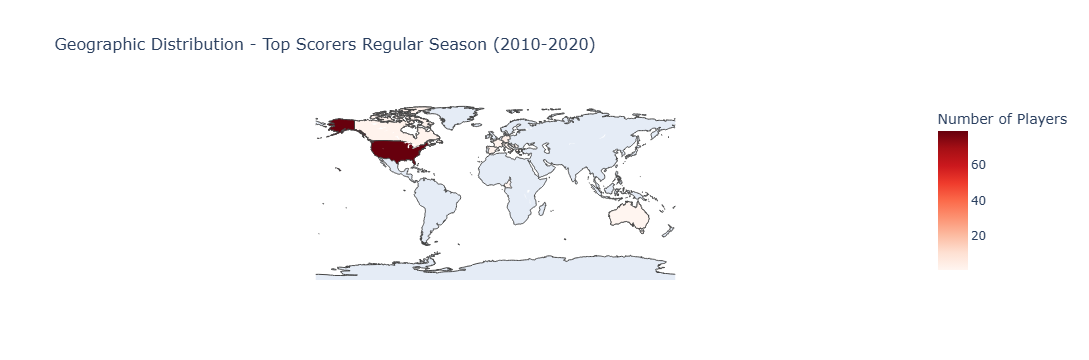

In [28]:
# MAP 1: Regular Season Top Scorers
fig1 = px.choropleth(
    country_counts_regular,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='Reds',
    title='Geographic Distribution - Top Scorers Regular Season (2010-2020)',
    labels={'player_count': 'Number of Players'}
)
fig1.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=True))
fig1.show()

C:\Users\Savvas\AppData\Local\Temp\ipykernel_18160\2990233365.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



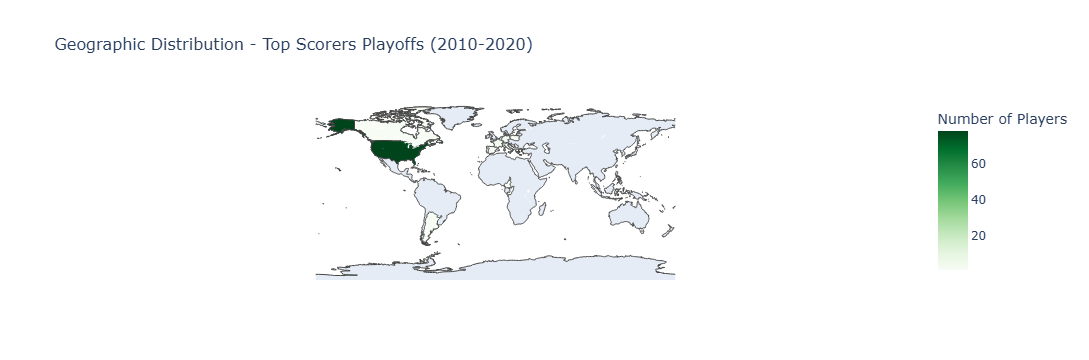

In [29]:
# MAP 2: Playoffs Top Scorers
fig2 = px.choropleth(
    country_counts_playoffs,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='Greens',
    title='Geographic Distribution - Top Scorers Playoffs (2010-2020)',
    labels={'player_count': 'Number of Players'}
)
fig2.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=True))
fig2.show()

C:\Users\Savvas\AppData\Local\Temp\ipykernel_18160\2656176284.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



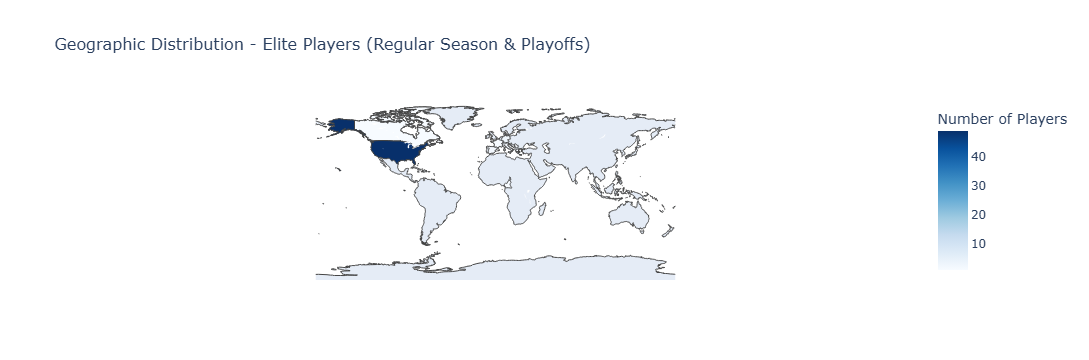

In [30]:
# MAP 3: Players appearing in both Regular Season and Playoffs
fig3 = px.choropleth(
    country_counts_common,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='Blues',
    title='Geographic Distribution - Elite Players (Regular Season & Playoffs)',
    labels={'player_count': 'Number of Players'}
)
fig3.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=True))
fig3.show()

In [31]:
print(country_counts_regular.sort_values('player_count', ascending=False).head(5))
print(country_counts_playoffs.sort_values('player_count', ascending=False).head(5))
print(country_counts_common.sort_values('player_count', ascending=False).head(5))
print(f"\nΣύνολο common players: {len(common_df)}")

          country  player_count
15  United States            79
8         Germany             3
4          Canada             2
7          France             2
10          Italy             2
          country  player_count
16  United States            78
6          France             3
7         Germany             3
15          Spain             2
9           Italy             2
                   country  player_count
12           United States            49
6                  Germany             3
8                    Italy             2
11                   Spain             2
0   Bosnia and Herzegovina             1

Σύνολο common players: 65


# Conclusions


- Higher draft selections achieve stronger average performance.
- Draft position does not guarantee future success.
- The NBA remains highly competitive.
- Elite scorers increasingly come from a diverse range of countries.